## Spatial Filtering

In [44]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os


In [113]:
image_path = 'images\Lenna.png' 
image_path = 'images\plot.png' 


In [114]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, 
                   cv2.COLOR_BGR2GRAY)

In [115]:
kernel_size = 5

In [116]:
img_average = cv2.blur(img, 
                       (kernel_size, kernel_size))

sigma_value = 0
img_gaussian = cv2.GaussianBlur(img, 
                                (kernel_size, kernel_size), 
                                sigma_value)

img_median = cv2.medianBlur(img, 
                            kernel_size)

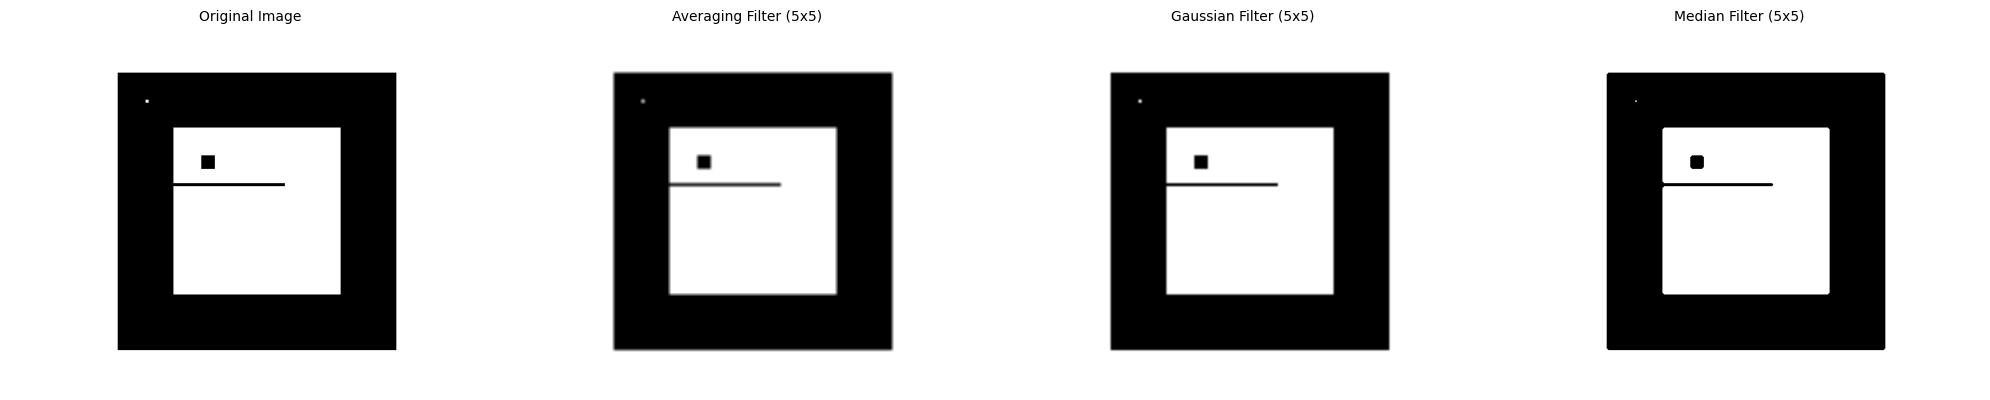

In [117]:

titles = ['Original Image', 'Averaging Filter (5x5)', 'Gaussian Filter (5x5)', 'Median Filter (5x5)']
images = [img, img_average, img_gaussian, img_median]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(images[i], cmap='gray')
    ax.set_title(titles[i], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Edge Detecction

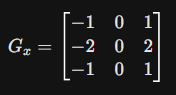 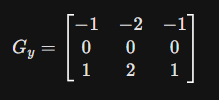

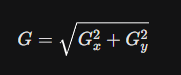

In [124]:
image_path = 'images\Lenna.png' 
image_path = 'images\plot.png' 

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [125]:
ddepth = cv2.CV_64F
k_size = 3 

sobelx = cv2.Sobel(img, 
                   ddepth, 
                   1, 
                   0, 
                   ksize=k_size)

sobely = cv2.Sobel(img, 
                   ddepth, 
                   0, 
                   1, 
                   ksize=k_size)

In [126]:
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)

In [127]:
sobel_combined = cv2.addWeighted(sobelx_abs, 
                                 0.5, 
                                 sobely_abs, 
                                 0.5, 
                                 0)

In [128]:
low_threshold = 100
high_threshold = 200
edges_canny = cv2.Canny(img, 
                        low_threshold, 
                        high_threshold)

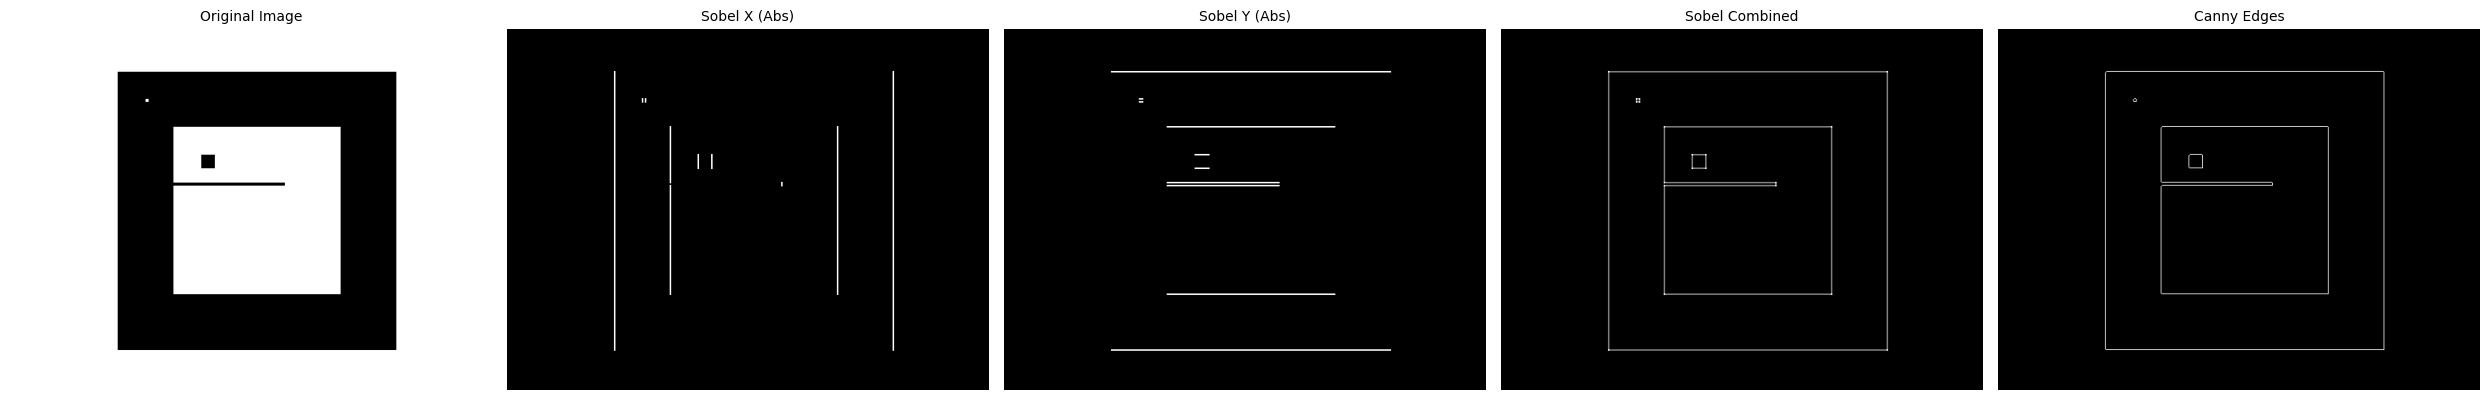

In [129]:
titles = [
    'Original Image', 
    'Sobel X (Abs)', 
    'Sobel Y (Abs)', 
    'Sobel Combined', 
    'Canny Edges'
]
images = [img, 
          sobelx_abs, 
          sobely_abs, 
          sobel_combined, 
          edges_canny]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(titles[i], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## morph

In [130]:
image_path = 'images\plot.png' 
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [131]:
kernel_size = 5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

In [ ]:
img_eroded = cv2.erode(img, kernel, iterations=1)
plt.imshow(img_eroded)


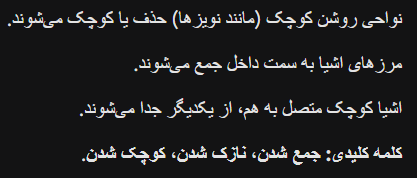

In [ ]:
img_dilated = cv2.dilate(img, kernel, iterations=1)
plt.imshow(img_dilated)

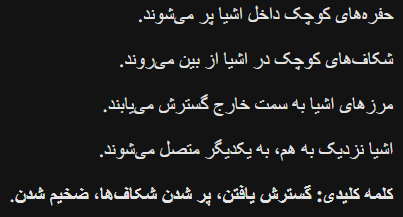

In [ ]:
img_opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
plt.imshow(img_opened)

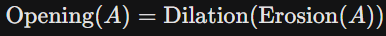

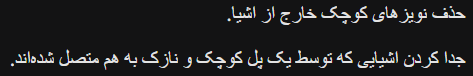

In [ ]:
img_closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
plt.imshow(img_closed)

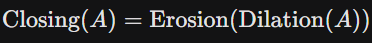

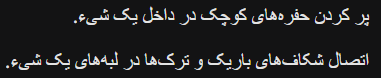

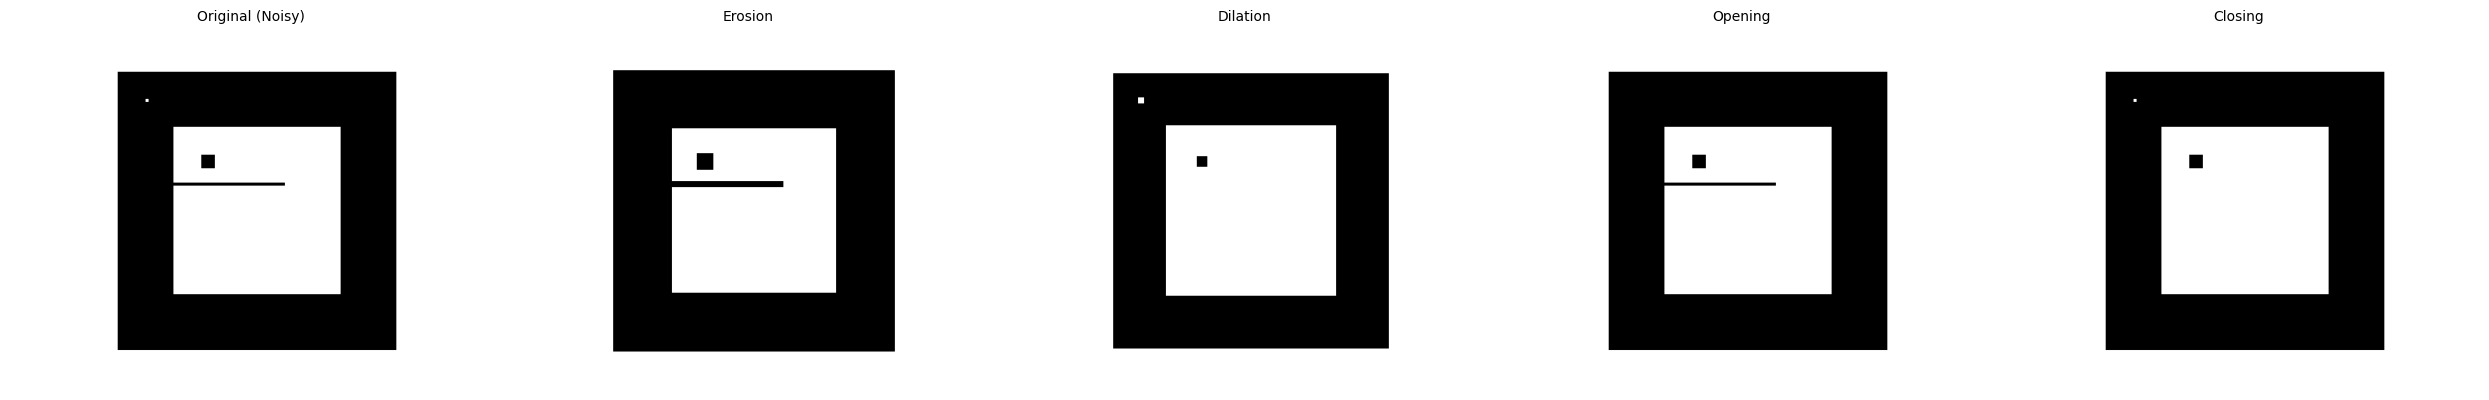

In [136]:
titles = ['Original (Noisy)', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [img, img_eroded, img_dilated, img_opened, img_closed]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(titles[i], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()